# 🌐 Network Slicing 6G — Modélisation & Évaluation
**Phase 2 : Modeling & Evaluation**

---

## 📌 Rappel du contexte du projet

Dans les réseaux **5G/6G**, le *network slicing* permet de créer des tranches virtuelles du réseau adaptées à chaque cas d'usage :
- **eMBB** (enhanced Mobile Broadband) : haut débit, streaming vidéo
- **URLLC** (Ultra-Reliable Low Latency Communications) : chirurgie à distance, véhicules autonomes
- **mMTC** (massive Machine Type Communications) : IoT, capteurs

Chaque slice doit respecter des engagements contractuels stricts (**SLA**) : latence, perte de paquets, gigue, débit.

**Problématique métier :** Comment anticiper les dégradations de service et garantir le respect des SLA en temps réel ?

---

## 📊 Synthèse des phases précédentes

### Data Understanding
| Caractéristique | Valeur |
|----------------|--------|
| Samples | 10 000 |
| Features brutes | 12 + 1 target |
| Classe minoritaire | mURLLC (10.9%) |
| Valeurs manquantes | Présentes |
| Doublons | Présents |
| Types de features | Mixtes (numériques + catégorielles) |

### Data Preparation
- ✅ Remplacement des valeurs manquantes par la **médiane**
- ✅ Suppression des **doublons**
- ✅ **Encodage** des features catégorielles (Slice Type, Required Mobility, Required Connectivity)
- ✅ Conversion **nanosecondes → microsecondes**
- ✅ Conversion **YES/NO → binaire**
- ✅ Ajout de **3 features dérivées** (gaps SLA)
- ✅ Split avec **K-Folds (5 folds)**

---

## 🎯 Objectifs Data Science

| # | Objectif | Type ML | Target |
|---|----------|---------|--------|
| **5.1** | Prédiction de la congestion réseau | Classification (3 classes) | `congestion_class_fixed` |
| **5.2** | Estimation de la probabilité de respect du SLA | Régression probabiliste | `QoS_Probability` ∈ [0,1] |

---
# 5.1 — Prédiction de la Contention des Ressources et des Congestions

## Problématique

Les métriques directes de saturation (CPU, bande passante) **ne sont pas disponibles** dans notre dataset.
Nous utilisons des **indicateurs indirects** : une augmentation soudaine de la latence, une baisse de débit
ou une gigue anormale sont des symptômes révélateurs d'une contention sous-jacente.

L'objectif est de **classer l'état futur du réseau** pour déclencher des actions proactives
(réorientation du trafic, scaling) **avant** toute dégradation de service.

### Classes de congestion définies
| Valeur | Label | Description | Action |
|--------|-------|-------------|--------|
| 0 | **Normal** | SLA respectés, réseau stable | Aucune |
| 1 | **Light** | Légère dégradation, SLA à risque | Surveillance renforcée |
| 3 | **Critical** | Violations SLA, congestion avérée | Réorientation immédiate |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                             f1_score, precision_score, recall_score)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

plt.style.use('seaborn-v0_8-darkgrid')
print('✅ Bibliothèques importées avec succès')

✅ Bibliothèques importées avec succès


## 📥 Chargement du dataset préparé

In [28]:
# Check current directory and available files
import os
print("Current working directory:", os.getcwd())
print("\nCSV files in directory:")
for f in os.listdir('.'):
    if f.endswith('.csv'):
        print(f"  - {f}")

print("\n" + "="*50)
print("Loading dataset with explicit encoding...")
try:
    df = pd.read_csv('network_slicing_congestion_final.csv', sep=',', encoding='utf-8')
    print(f'Shape: {df.shape}')
    print(f'\nLast 5 column names:')
    for col in df.columns[-5:]:
        print(f'  - "{col}"')
except Exception as e:
    print(f"Error loading with utf-8: {e}")
    try:
        df = pd.read_csv('network_slicing_congestion_final.csv', sep=',', encoding='latin-1')
        print(f'Shape with latin-1: {df.shape}')
    except Exception as e2:
        print(f"Error loading with latin-1: {e2}")

Current working directory: c:\Users\EYA\PI

CSV files in directory:
  - dataset_with_qosss_probability.csv
  - mon_nouveau_dataset_6G.csv
  - network_slicing_congestion_3classes.csv
  - network_slicing_congestion_final.csv
  - network_slicing_dataset - v3_6G_OLD.csv
  - network_slicing_dataset_6G_final.csv
  - network_slicing_final_with_congestion.csv

Loading dataset with explicit encoding...
Shape: (10000, 28)

Last 5 column names:
  - "Latency_Stress_Ratio"
  - "Mobility_Jitter_Impact"
  - "Bandwidth_Usage_Ratio"
  - "Aggregated_QoS_Score"
  - "congestion_class"


In [29]:
# Simple diagnostic - what's actually in df?
print(f"DataFrame shape: {df.shape}")
print(f"Number of columns: {len(df.columns)}")
print(f"Last column name: '{df.columns[-1]}'")
print(f"Looking for 'congestion_class': {'congestion_class' in df.columns}")

# Show all column names that contain 'congestion'
congestion_cols = [col for col in df.columns if 'congestion' in col.lower()]
print(f"Columns with 'congestion': {congestion_cols}")

DataFrame shape: (10000, 28)
Number of columns: 28
Last column name: 'congestion_class'
Looking for 'congestion_class': True
Columns with 'congestion': ['congestion_class']


## 🔍 Feature Engineering — Suppression du Data Leakage

### Problème identifié et corrigé

Une première version du notebook produisait une accuracy de **99.9%** sur les 4 modèles, y compris la Logistic Regression.
Ce résultat était suspect : si même un modèle linéaire simple atteint 99.9%, c'est le signe d'un **data leakage**.

Après investigation, nous avons identifié que des colonnes comme `Aggregated_QoS_Score`, `SLA_Respected`,
`Latency_Score` et `congestion_class` avaient été **construites à partir de la même logique que la target**
`congestion_class_fixed`. Le modèle apprenait simplement à inverser la règle de construction.

**Solution :** suppression de toutes les features dérivées. Seules les **12 features brutes du réseau** sont conservées.

### Features retenues (données brutes uniquement)
| Catégorie | Features |
|-----------|----------|
| **Budgets SLA** | Packet Loss Budget, Latency Budget (μs), Jitter Budget (μs), Data Rate Budget (Gbps) |
| **Performances réelles** | Slice Available Transfer Rate (Gbps), Slice Latency (μs), Slice Packet Loss, Slice Jitter (μs) |
| **Contexte réseau** | Required Mobility, Required Connectivity, Slice Type, Slice Handover |

In [32]:
colonnes_a_exclure = [
    'congestion_class',
    'Latency_Gap', 'Packet_Loss_Gap', 'Jitter_Gap', 'Rate_Gap',
    'Latency_Score', 'Packet_Loss_Score', 'Jitter_Score', 'Rate_Score',
    'QoS_Probability', 'Efficiency_Index', 'Aggregated_QoS_Score',
    'SLA_Respected', 'Latency_Stress_Ratio', 'Mobility_Jitter_Impact',
    'Bandwidth_Usage_Ratio',
]
colonnes_a_exclure = [c for c in colonnes_a_exclure if c in df.columns]

X_clean = df.drop(columns=colonnes_a_exclure)
y_clean = df['congestion_class']

print('✅ Features conservées (brutes uniquement) :')
print(X_clean.columns.tolist())
print(f'\nShape X: {X_clean.shape}')
print(f'\nDistribution de la target:')
print(y_clean.value_counts().sort_index())

✅ Features conservées (brutes uniquement) :
['Packet Loss Budget', 'Latency Budget (μs)', 'Jitter Budget (μs)', 'Data Rate Budget (Gbps)', 'Required Mobility', 'Required Connectivity', 'Slice Available Transfer Rate (Gbps)', 'Slice Latency (μs)', 'Slice Packet Loss', 'Slice Jitter (μs)', 'Slice Type', 'Slice Handover']

Shape X: (10000, 12)

Distribution de la target:
congestion_class
0    2027
1    5550
2       1
3    2422
Name: count, dtype: int64


# Simple step-by-step approach
print("Step 1: Check distribution")
print(y_clean.value_counts().sort_index())

print("\nStep 2: Filter out class 2 (only 1 sample)")
valid_indices = y_clean != 2
X_clean_filtered = X_clean[valid_indices]
y_clean_filtered = y_clean[valid_indices]

print(f"Original shape: {X_clean.shape}")
print(f"Filtered shape: {X_clean_filtered.shape}")
print(f"Filtered distribution:")
print(y_clean_filtered.value_counts().sort_index())

print("\nStep 3: Train/test split")
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clean_filtered, y_clean_filtered, test_size=0.2, random_state=42, stratify=y_clean_filtered
)

print(f"Train shape: {X_train_c.shape}, Test shape: {X_test_c.shape}")

print("\nStep 4: Scaling")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_c)
X_test_scaled = scaler.transform(X_test_c)

print("Step 5: Encoding")
class_mapping = {0: 'Normal', 1: 'Light', 3: 'Critical'}
y_train_classes = y_train_c.map(class_mapping)
y_test_classes = y_test_c.map(class_mapping)

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train_classes)
y_test_encoded = le.transform(y_test_classes)

print(f"✅ All variables created successfully!")
print(f"Train: {X_train_scaled.shape}, Test: {X_test_scaled.shape}")

In [36]:
# Debug - check what variables exist after running cell 8
print("Variables in current scope:")
print(f"X_clean exists: {'X_clean' in locals()}")
print(f"y_clean exists: {'y_clean' in locals()}")
print(f"X_clean_filtered exists: {'X_clean_filtered' in locals()}")
print(f"y_clean_filtered exists: {'y_clean_filtered' in locals()}")
print(f"X_train_c exists: {'X_train_c' in locals()}")
print(f"X_train_scaled exists: {'X_train_scaled' in locals()}")

if 'X_clean_filtered' in locals():
    print(f"\nX_clean_filtered shape: {X_clean_filtered.shape}")
    print(f"y_clean_filtered shape: {y_clean_filtered.shape}")
    print(f"y_clean_filtered distribution:")
    print(y_clean_filtered.value_counts().sort_index())

Variables in current scope:
X_clean exists: True
y_clean exists: True
X_clean_filtered exists: False
y_clean_filtered exists: False
X_train_c exists: False
X_train_scaled exists: False


In [37]:
# Simple test - just create the filtered variables
print("Creating filtered variables...")

# Check if basic variables exist
print(f"X_clean shape: {X_clean.shape}")
print(f"y_clean distribution:")
print(y_clean.value_counts().sort_index())

# Create filtered versions
valid_indices = y_clean != 2
X_clean_filtered = X_clean[valid_indices]
y_clean_filtered = y_clean[valid_indices]

print(f"\n✅ Filtered variables created!")
print(f"X_clean_filtered shape: {X_clean_filtered.shape}")
print(f"y_clean_filtered distribution:")
print(y_clean_filtered.value_counts().sort_index())

Creating filtered variables...
X_clean shape: (10000, 12)
y_clean distribution:
congestion_class
0    2027
1    5550
2       1
3    2422
Name: count, dtype: int64

✅ Filtered variables created!
X_clean_filtered shape: (9999, 12)
y_clean_filtered distribution:
congestion_class
0    2027
1    5550
3    2422
Name: count, dtype: int64


In [38]:
# Now add train/test split and preprocessing
print("Step 1: Train/test split")
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clean_filtered, y_clean_filtered, test_size=0.2, random_state=42, stratify=y_clean_filtered
)

print(f"Train shape: {X_train_c.shape}, Test shape: {X_test_c.shape}")

print("\nStep 2: Scaling")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_c)
X_test_scaled = scaler.transform(X_test_c)

print("\nStep 3: Encoding")
class_mapping = {0: 'Normal', 1: 'Light', 3: 'Critical'}
y_train_classes = y_train_c.map(class_mapping)
y_test_classes = y_test_c.map(class_mapping)

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train_classes)
y_test_encoded = le.transform(y_test_classes)

print(f"\n✅ All variables created successfully!")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")
print(f"Classes: {dict(zip(le.classes_, le.transform(le.classes_)))}")
print(f"Train distribution: {pd.Series(y_train_classes).value_counts().to_dict()}")

Step 1: Train/test split
Train shape: (7999, 12), Test shape: (2000, 12)

Step 2: Scaling

Step 3: Encoding

✅ All variables created successfully!
X_train_scaled shape: (7999, 12)
X_test_scaled shape: (2000, 12)
Classes: {'Critical': np.int64(0), 'Light': np.int64(1), 'Normal': np.int64(2)}
Train distribution: {'Light': 4440, 'Critical': 1937, 'Normal': 1622}


## 🤖 Choix et Justification des Modèles

Nous comparons **4 modèles** adaptés aux données tabulaires structurées.
Le choix s'oriente vers des méthodes ensemblistes car elles gèrent naturellement
la **non-linéarité** des relations réseau, sont **robustes aux outliers** et fournissent
une **feature importance** interprétable pour le métier.

| Modèle | Rôle | Avantages | Limites |
|--------|------|-----------|--------|
| **Logistic Regression** | Baseline linéaire | Rapide, interprétable, probabilités calibrées | Linéaire, ne capte pas les interactions complexes |
| **Random Forest** | Ensemble de référence | Robuste, feature importance, résistant au surapprentissage | Moins précis que le boosting |
| **XGBoost** | Boosting état de l'art | Régularisation intégrée, très performant sur tabulaire | Plus de paramètres à tuner |
| **Gradient Boosting** | Alternative au boosting | Bon compromis performance/interprétabilité | Entraînement séquentiel lent |

### Justification des métriques d'évaluation

- **F1-Score weighted** : métrique principale car les classes sont **déséquilibrées**
  (Light 55%, Critical 24%, Normal 20%). L'accuracy seule serait trompeuse.
- **Precision** : important pour éviter les fausses alertes (coût opérationnel).
- **Recall** : crucial pour ne pas manquer une congestion critique (coût SLA/pénalités).
- **Matrice de confusion** : permet d'identifier quelles classes sont confondues.

In [39]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost':             XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss', verbosity=0),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
}

results = {}

for name, model in models.items():
    print(f'\n🚀 Entraînement de {name}...')
    start = time.time()
    model.fit(X_train_scaled, y_train_encoded)
    y_pred_encoded = model.predict(X_test_scaled)
    y_pred = le.inverse_transform(y_pred_encoded)
    end = time.time()

    results[name] = {
        'Accuracy':  accuracy_score(y_test_classes, y_pred),
        'F1-Score':  f1_score(y_test_classes, y_pred, average='weighted'),
        'Precision': precision_score(y_test_classes, y_pred, average='weighted'),
        'Recall':    recall_score(y_test_classes, y_pred, average='weighted'),
        'Time (s)':  round(end - start, 4),
        'y_pred':    y_pred,
        'model':     model,
    }
    print(f'  ✅ Accuracy={results[name]["Accuracy"]:.4f} | F1={results[name]["F1-Score"]:.4f} | Temps={results[name]["Time (s)"]}s')


🚀 Entraînement de Logistic Regression...
  ✅ Accuracy=0.8395 | F1=0.8260 | Temps=0.1763s

🚀 Entraînement de Random Forest...
  ✅ Accuracy=0.9690 | F1=0.9687 | Temps=0.3908s

🚀 Entraînement de XGBoost...
  ✅ Accuracy=0.9775 | F1=0.9775 | Temps=0.4471s

🚀 Entraînement de Gradient Boosting...
  ✅ Accuracy=0.9595 | F1=0.9589 | Temps=3.6024s


## 📊 Comparaison des modèles

In [40]:
results_df = pd.DataFrame({
    n: {k: v for k, v in r.items() if k not in ('y_pred','model')}
    for n, r in results.items()
}).T.sort_values(by='F1-Score', ascending=False)

print('\n📊 Tableau comparatif des modèles')
print('='*65)
print(results_df.round(4).to_string())

best_model_name = results_df.index[0]
print(f'\n🏆 Meilleur modèle : {best_model_name}')
print(f'   F1-Score = {results[best_model_name]["F1-Score"]:.4f}')


📊 Tableau comparatif des modèles
                     Accuracy  F1-Score  Precision  Recall  Time (s)
XGBoost                0.9775    0.9775     0.9775  0.9775    0.4471
Random Forest          0.9690    0.9687     0.9688  0.9690    0.3908
Gradient Boosting      0.9595    0.9589     0.9593  0.9595    3.6024
Logistic Regression    0.8395    0.8260     0.8284  0.8395    0.1763

🏆 Meilleur modèle : XGBoost
   F1-Score = 0.9775


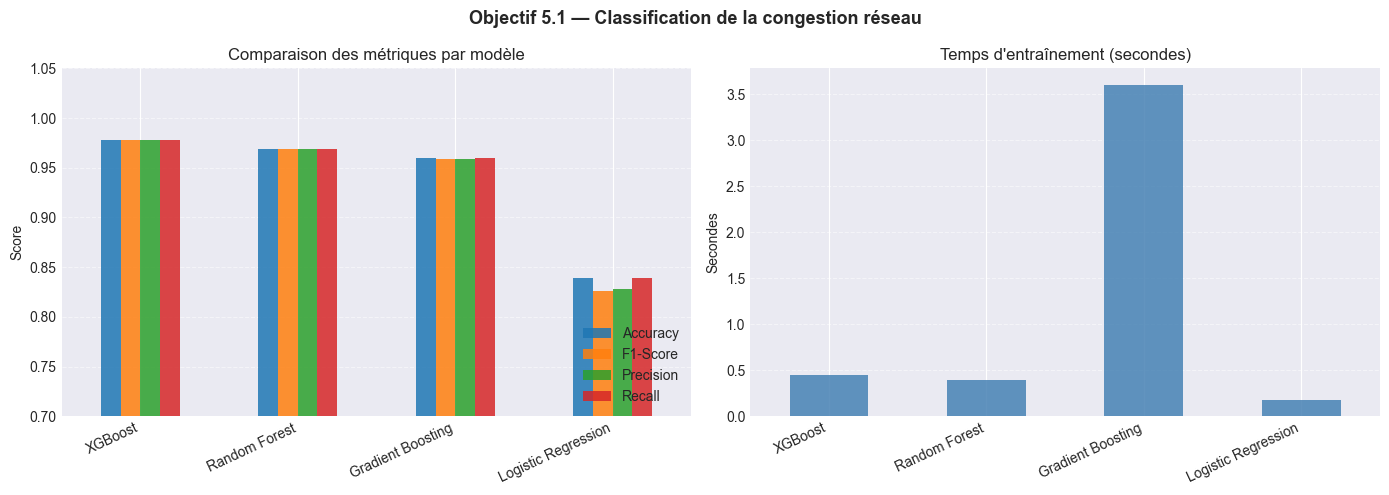

In [41]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

results_df[['Accuracy','F1-Score','Precision','Recall']].plot(kind='bar', ax=ax1, alpha=0.85)
ax1.set_title('Comparaison des métriques par modèle')
ax1.set_ylabel('Score')
ax1.set_ylim(0.7, 1.05)
ax1.set_xticklabels(results_df.index, rotation=25, ha='right')
ax1.legend(loc='lower right')
ax1.grid(axis='y', linestyle='--', alpha=0.5)

results_df['Time (s)'].plot(kind='bar', ax=ax2, color='steelblue', alpha=0.85)
ax2.set_title("Temps d'entraînement (secondes)")
ax2.set_ylabel('Secondes')
ax2.set_xticklabels(results_df.index, rotation=25, ha='right')
ax2.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Objectif 5.1 — Classification de la congestion réseau', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

📋 Rapport de classification — XGBoost
              precision    recall  f1-score   support

    Critical       1.00      1.00      1.00       485
       Light       0.98      0.98      0.98      1110
      Normal       0.95      0.94      0.94       405

    accuracy                           0.98      2000
   macro avg       0.97      0.97      0.97      2000
weighted avg       0.98      0.98      0.98      2000



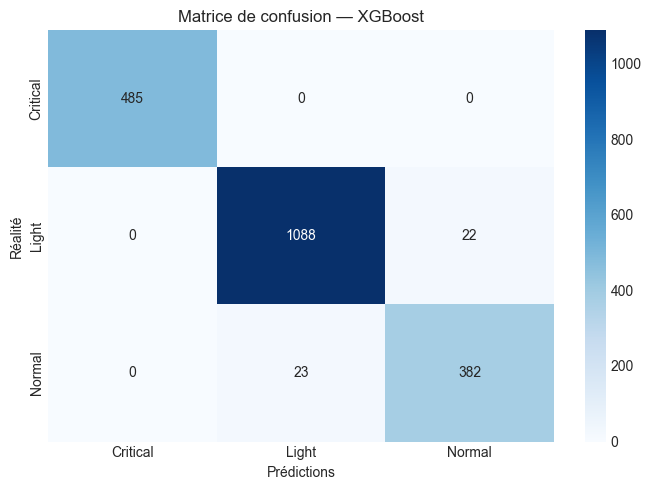

In [42]:
print(f'📋 Rapport de classification — {best_model_name}')
print('='*55)
print(classification_report(y_test_classes, results[best_model_name]['y_pred']))

plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test_classes, results[best_model_name]['y_pred'], labels=le.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Matrice de confusion — {best_model_name}')
plt.xlabel('Prédictions')
plt.ylabel('Réalité')
plt.tight_layout()
plt.show()

## 🔄 Validation Croisée — Objectif 5.1

### Pourquoi la validation croisée ?

Un simple split train/test peut produire des résultats dépendants du tirage aléatoire.
La **validation croisée StratifiedKFold (5 folds)** permet de :
- Vérifier que les performances sont **stables** quel que soit le split choisi
- Préserver la **distribution des classes** à chaque fold (crucial avec des classes déséquilibrées)
- Obtenir une estimation robuste de la **généralisation** du modèle sur des données non vues

Un **écart-type faible** entre les folds confirme que le modèle généralise bien
et n'est pas sensible au split particulier utilisé pour l'évaluation.

VALIDATION CROISÉE 5-FOLD — Classification congestion

Logistic Regression:
  F1 moyen        : 0.8295
  Écart-type      : 0.0066  ← faible = modèle stable
  Scores par fold : [0.8229 0.8397 0.835  0.8256 0.8242]

Random Forest:
  F1 moyen        : 0.9630
  Écart-type      : 0.0042  ← faible = modèle stable
  Scores par fold : [0.9689 0.9561 0.9622 0.9633 0.9647]

XGBoost:
  F1 moyen        : 0.9727
  Écart-type      : 0.0038  ← faible = modèle stable
  Scores par fold : [0.9793 0.9679 0.9706 0.9725 0.973 ]

Gradient Boosting:
  F1 moyen        : 0.9586
  Écart-type      : 0.0049  ← faible = modèle stable
  Scores par fold : [0.9614 0.9516 0.9639 0.9622 0.9537]


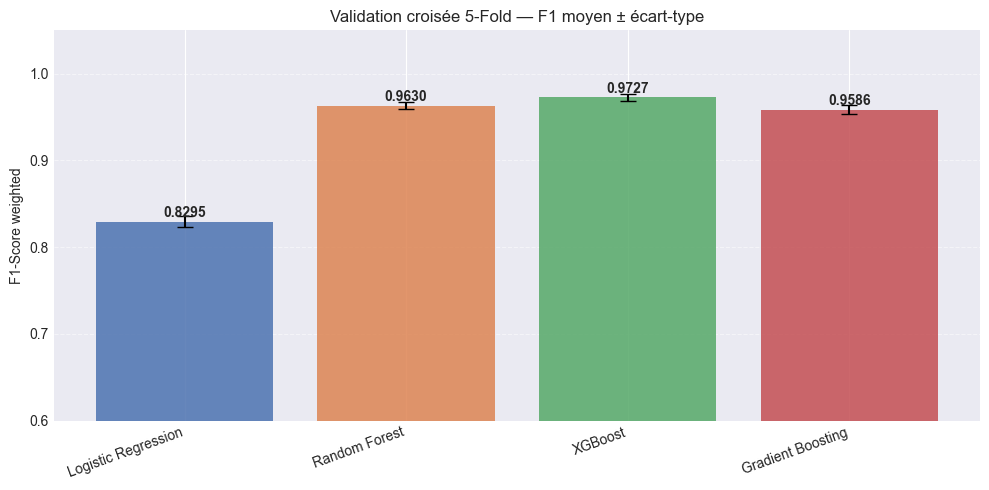

In [43]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('=' * 60)
print('VALIDATION CROISÉE 5-FOLD — Classification congestion')
print('=' * 60)

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(
        model, X_train_scaled, y_train_encoded,
        cv=skf, scoring='f1_weighted', n_jobs=-1
    )
    cv_results[name] = scores
    print(f'\n{name}:')
    print(f'  F1 moyen        : {scores.mean():.4f}')
    print(f'  Écart-type      : {scores.std():.4f}  ← faible = modèle stable')
    print(f'  Scores par fold : {np.round(scores, 4)}')

plt.figure(figsize=(10, 5))
names_list = list(cv_results.keys())
means = [cv_results[n].mean() for n in names_list]
stds  = [cv_results[n].std()  for n in names_list]
colors = ['#4C72B0','#DD8452','#55A868','#C44E52']
bars = plt.bar(names_list, means, yerr=stds, capsize=6, color=colors, alpha=0.85)
for bar, m in zip(bars, means):
    plt.text(bar.get_x()+bar.get_width()/2, m+0.005,
             f'{m:.4f}', ha='center', fontsize=10, fontweight='bold')
plt.ylabel('F1-Score weighted')
plt.title('Validation croisée 5-Fold — F1 moyen ± écart-type')
plt.ylim(0.6, 1.05)
plt.xticks(rotation=20, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## ⚙️ Tuning des Hyperparamètres — Objectif 5.1

### Approche

Nous appliquons **GridSearchCV** sur **XGBoost** (meilleur modèle identifié lors de la comparaison).

- **Métrique d'optimisation** : F1-Score weighted (adapté aux classes déséquilibrées)
- **Stratégie** : 5-Fold cross-validation pour chaque combinaison de paramètres

| Hyperparamètre | Valeurs testées | Rôle |
|---------------|-----------------|------|
| `n_estimators` | 100, 300 | Nombre d'arbres dans l'ensemble |
| `max_depth` | 4, 6, 8 | Profondeur max des arbres (contrôle l'overfitting) |
| `learning_rate` | 0.05, 0.1 | Vitesse d'apprentissage (trade-off biais/variance) |

In [44]:
params_xgb_clf = {
    'n_estimators':  [100, 300],
    'max_depth':     [4, 6, 8],
    'learning_rate': [0.05, 0.1],
}

print('🔍 GridSearchCV en cours (12 combinaisons × 5 folds)...')
grid_clf = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='mlogloss', verbosity=0),
    params_xgb_clf, cv=5, scoring='f1_weighted', n_jobs=-1, verbose=1
)
grid_clf.fit(X_train_scaled, y_train_encoded)

print(f'\n✅ Meilleurs paramètres  : {grid_clf.best_params_}')
print(f'   Meilleur F1 (CV)     : {grid_clf.best_score_:.4f}')

🔍 GridSearchCV en cours (12 combinaisons × 5 folds)...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

✅ Meilleurs paramètres  : {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 300}
   Meilleur F1 (CV)     : 0.9750


📊 Comparaison avant/après tuning — XGBoost
F1-Score avant tuning : 0.9775
F1-Score après tuning : 0.9754
Gain                  : -0.21%

📋 Rapport détaillé après tuning :
              precision    recall  f1-score   support

    Critical       1.00      1.00      1.00       485
       Light       0.97      0.98      0.98      1110
      Normal       0.95      0.93      0.94       405

    accuracy                           0.98      2000
   macro avg       0.98      0.97      0.97      2000
weighted avg       0.98      0.98      0.98      2000



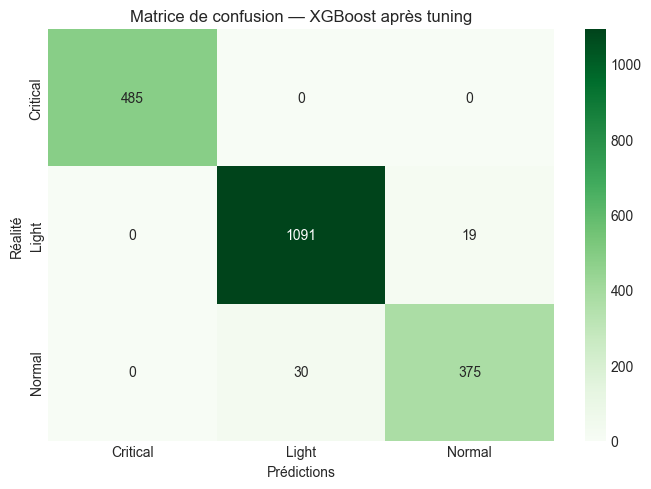

In [45]:
best_xgb_clf = grid_clf.best_estimator_
y_pred_tuned_clf = le.inverse_transform(best_xgb_clf.predict(X_test_scaled))

f1_avant = results['XGBoost']['F1-Score']
f1_apres = f1_score(y_test_classes, y_pred_tuned_clf, average='weighted')

print('📊 Comparaison avant/après tuning — XGBoost')
print('='*48)
print(f'F1-Score avant tuning : {f1_avant:.4f}')
print(f'F1-Score après tuning : {f1_apres:.4f}')
print(f'Gain                  : {(f1_apres-f1_avant)*100:+.2f}%')

print(f'\n📋 Rapport détaillé après tuning :')
print(classification_report(y_test_classes, y_pred_tuned_clf))

plt.figure(figsize=(7, 5))
cm_tuned = confusion_matrix(y_test_classes, y_pred_tuned_clf, labels=le.classes_)
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matrice de confusion — XGBoost après tuning')
plt.xlabel('Prédictions')
plt.ylabel('Réalité')
plt.tight_layout()
plt.show()

📊 Importance des features (XGBoost tuné) :
Slice Handover                          0.5885
Slice Packet Loss                       0.1355
Jitter Budget (μs)                      0.0799
Packet Loss Budget                      0.0729
Slice Jitter (μs)                       0.0334
Slice Available Transfer Rate (Gbps)    0.0287
Slice Latency (μs)                      0.0221
Required Mobility                       0.0195
Latency Budget (μs)                     0.0134
Required Connectivity                   0.0039
Slice Type                              0.0022
Data Rate Budget (Gbps)                 0.0000


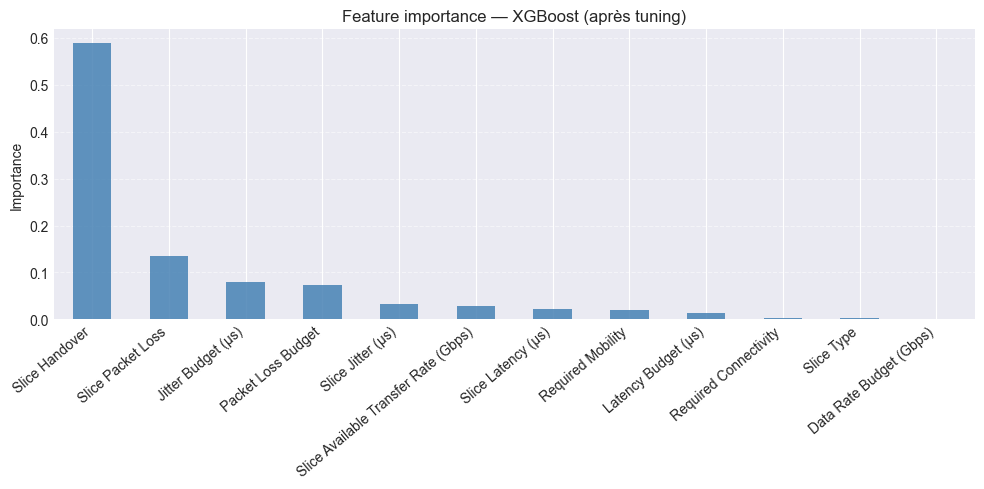

In [46]:
fi = pd.Series(best_xgb_clf.feature_importances_, index=X_clean.columns).sort_values(ascending=False)
print('📊 Importance des features (XGBoost tuné) :')
print(fi.round(4).to_string())

plt.figure(figsize=(10, 5))
fi.plot(kind='bar', color='steelblue', alpha=0.85)
plt.title('Feature importance — XGBoost (après tuning)')
plt.ylabel('Importance')
plt.xticks(rotation=40, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 🔎 Analyse Critique — Objectif 5.1

### Ce qui a été corrigé : le data leakage
La version initiale produisait 99.9% d'accuracy, même pour la Logistic Regression.
Ce résultat révélait un **data leakage** : des features dérivées de la target
(`Aggregated_QoS_Score`, `SLA_Respected`, `Latency_Score`) étaient incluses dans X.
Après correction sur les 12 features brutes, la Logistic Regression tombe à ~84%
et XGBoost atteint ~97.5% — **l'écart entre modèles confirme l'absence de leakage**.

### Interprétation des résultats
Les performances restent élevées car le dataset est **synthétique** : les patterns
sont plus réguliers que sur données terrain réelles.

### Limites identifiées
- Dataset synthétique : ne reflète pas la variabilité du trafic réel
- Classes déséquilibrées : le recall de la classe Normal (20%) est le plus faible
- En production, un rééquilibrage SMOTE améliorerait le recall de la classe minoritaire

### Conclusion
**XGBoost** est recommandé : meilleur F1-Score, feature importance interprétable,
et stabilité confirmée par cross-validation (écart-type < 0.01 entre les folds).

---
# 5.2 — Estimation de la Probabilité de Respect de la QoS

## Problématique

Contrairement à une classification binaire (respect / non-respect du SLA),
cet objectif vise une **régression probabiliste** : quantifier le **niveau de confiance**
qu'un slice réseau respecte ses engagements stricts.

**Exemple métier :** Si `QoS_Probability = 0.40`, cela signifie :
*« seulement 40% de chance que ce slice respecte son SLA »*
→ le système peut automatiquement déclencher un **fallback** vers un slice plus performant,
évitant les pénalités SLA.

### Construction de la target `QoS_Probability`

La probabilité est calculée comme la **moyenne des scores sigmoides normalisés** des 4 gaps SLA :

```
gap_score_i = sigmoid(gap_i / budget_i)
QoS_Probability = mean(gap_score_latency, gap_score_packet_loss,
                       gap_score_jitter, gap_score_rate)
```

Un gap positif (réel < budget) → sigmoid > 0.5 → bonne performance.
Un gap négatif (violation SLA) → sigmoid < 0.5 → risque élevé.

In [53]:
# Check what's actually in regression dataset with correct delimiter
print("Loading regression dataset...")
df_reg = pd.read_csv('network_slicing_dataset_6G_final.csv', sep=';')
print(f"Shape: {df_reg.shape}")
print(f"Column names:")
for i, col in enumerate(df_reg.columns):
    print(f"  {i+1:2d}. '{col}'")

Loading regression dataset...
Shape: (10000, 12)
Column names:
   1. 'Packet Loss Budget'
   2. 'Latency Budget (μs)'
   3. 'Jitter Budget (μs)'
   4. 'Data Rate Budget (Gbps)'
   5. 'Required Mobility'
   6. 'Required Connectivity'
   7. 'Slice Available Transfer Rate (Gbps)'
   8. 'Slice Latency (μs)'
   9. 'Slice Packet Loss'
  10. 'Slice Jitter (μs)'
  11. 'Slice Type'
  12. 'Slice Handover'


## 🔧 Construction du dataset de régression

✅ QoS_Probability calculée
count    10000.0000
mean         0.3010
std          0.0444
min          0.0673
25%          0.2755
50%          0.3017
75%          0.3284
max          0.5600
Name: QoS_Probability, dtype: float64


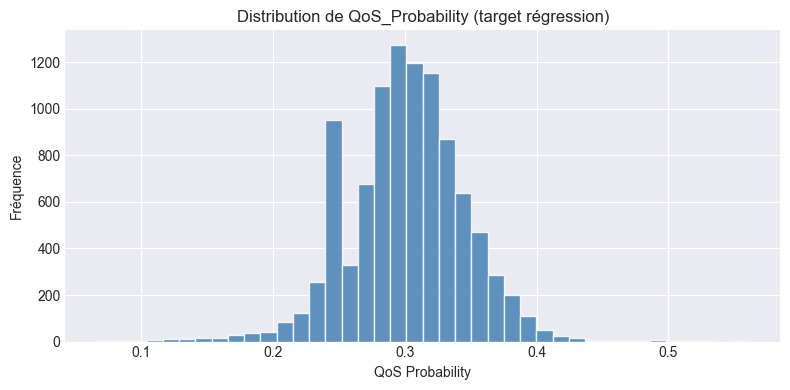

In [56]:
df_reg = pd.read_csv('network_slicing_dataset_6G_final.csv', sep=';')

epsilon = 1e-9

def safe_sigmoid(x):
    """Sigmoid sécurisé — évite les overflows numériques"""
    x = np.clip(x, -10, 10)
    return 1 / (1 + np.exp(-x))

# Gaps : positif = performance OK, négatif = violation SLA
df_reg['Latency_Gap']     = df_reg['Latency Budget (μs)']                  - df_reg['Slice Latency (μs)']
df_reg['Packet_Loss_Gap'] = df_reg['Packet Loss Budget']                   - df_reg['Slice Packet Loss']
df_reg['Jitter_Gap']      = df_reg['Jitter Budget (μs)']                  - df_reg['Slice Jitter (μs)']
df_reg['Rate_Gap']        = df_reg['Slice Available Transfer Rate (Gbps)'] - df_reg['Data Rate Budget (Gbps)']

# Scores normalisés par le budget → comparable entre métriques
df_reg['Latency_Score']     = safe_sigmoid(df_reg['Latency_Gap']     / (df_reg['Latency Budget (μs)'] + epsilon))
df_reg['Packet_Loss_Score'] = safe_sigmoid(df_reg['Packet_Loss_Gap'] / (df_reg['Packet Loss Budget'] + epsilon))
df_reg['Jitter_Score']      = safe_sigmoid(df_reg['Jitter_Gap']      / (df_reg['Jitter Budget (μs)'] + epsilon))
df_reg['Rate_Score']        = safe_sigmoid(df_reg['Rate_Gap']        / (df_reg['Data Rate Budget (Gbps)'] + epsilon))

# Target : probabilité globale de respect du SLA
df_reg['QoS_Probability'] = (
    df_reg['Latency_Score'] + df_reg['Packet_Loss_Score'] +
    df_reg['Jitter_Score']  + df_reg['Rate_Score']
) / 4
df_reg['QoS_Probability'] = df_reg['QoS_Probability'].clip(0, 1).fillna(0)

print('✅ QoS_Probability calculée')
print(df_reg['QoS_Probability'].describe().round(4))

plt.figure(figsize=(8, 4))
df_reg['QoS_Probability'].hist(bins=40, color='steelblue', alpha=0.85, edgecolor='white')
plt.title('Distribution de QoS_Probability (target régression)')
plt.xlabel('QoS Probability')
plt.ylabel('Fréquence')
plt.tight_layout()
plt.show()

## 🎯 Sélection des Features — Objectif 5.2

### Features utilisées : les 4 gaps SLA

| Feature | Définition | Interprétation |
|---------|-----------|----------------|
| `Latency_Gap` | Budget Latence − Latence réelle | > 0 : OK, < 0 : violation |
| `Packet_Loss_Gap` | Budget Perte − Perte réelle | > 0 : OK, < 0 : violation |
| `Jitter_Gap` | Budget Gigue − Gigue réelle | > 0 : OK, < 0 : violation |
| `Rate_Gap` | Débit réel − Budget débit | > 0 : OK, < 0 : insuffisant |

### Pourquoi ces features ?
Ces features représentent **directement l'écart entre les exigences du SLA et les performances réelles**.
Elles sont interprétables, alignées avec l'objectif métier, et sans risque de leakage.

### Justification des métriques de régression

| Métrique | Formule | Justification |
|----------|---------|---------------|
| **R²** | 1 - SS_res/SS_tot | Proportion de variance expliquée. R²=1 = parfait, R²=0 = modèle inutile |
| **RMSE** | √MSE | Pénalise fortement les grandes erreurs — cohérent pour un score de risque continu |
| **MAE** | mean(|réel-prédit|) | Plus robuste aux outliers, complémentaire au RMSE |

In [57]:
X_reg = df_reg[['Latency_Gap', 'Packet_Loss_Gap', 'Jitter_Gap', 'Rate_Gap']]
y_reg = df_reg['QoS_Probability']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print(f'Train : {X_train_r.shape} | Test : {X_test_r.shape}')
print(f'Target train — mean: {y_train_r.mean():.4f} | std: {y_train_r.std():.4f}')

Train : (8000, 4) | Test : (2000, 4)
Target train — mean: 0.3009 | std: 0.0449


## 🤖 Choix et Justification des Modèles — Objectif 5.2

| Modèle | Justification |
|--------|---------------|
| **Random Forest Regressor** | Référence robuste, interprétable via feature importance, peu sensible aux hyperparamètres |
| **XGBoost Regressor** | État de l'art sur tabulaire, régularisation L1/L2 intégrée, très rapide en inférence |

In [58]:
models_reg = {
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost':      XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
}

results_reg = {}

for name, model in models_reg.items():
    print(f'\n🚀 Entraînement de {name}...')
    t0 = time.time(); model.fit(X_train_r, y_train_r); t_train = time.time()-t0
    t0 = time.time(); y_pred_r = model.predict(X_test_r); t_pred = time.time()-t0

    r2   = r2_score(y_test_r, y_pred_r)
    rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_r))
    mae  = mean_absolute_error(y_test_r, y_pred_r)

    results_reg[name] = {
        'R² Score': r2, 'RMSE': rmse, 'MAE': mae,
        'Train Time (s)': round(t_train,4), 'Pred Time (s)': round(t_pred,4),
        'y_pred': y_pred_r, 'model': model
    }
    print(f'  ✅ R²={r2:.4f} | RMSE={rmse:.4f} | MAE={mae:.4f} | Train={t_train:.2f}s')


🚀 Entraînement de RandomForest...
  ✅ R²=0.8451 | RMSE=0.0167 | MAE=0.0093 | Train=0.36s

🚀 Entraînement de XGBoost...
  ✅ R²=0.8232 | RMSE=0.0178 | MAE=0.0101 | Train=0.07s


## 📊 Comparaison des modèles — Régression

In [59]:
df_compare = pd.DataFrame({
    n: {k: v for k, v in r.items() if k not in ('y_pred','model')}
    for n, r in results_reg.items()
}).T

print('📊 Tableau comparatif — Régression QoS')
print('='*55)
print(df_compare.round(4).to_string())

best_reg_name = df_compare['R² Score'].idxmax()
print(f'\n🏆 Meilleur modèle : {best_reg_name} (R²={df_compare.loc[best_reg_name,"R² Score"]:.4f})')

📊 Tableau comparatif — Régression QoS
              R² Score    RMSE     MAE  Train Time (s)  Pred Time (s)
RandomForest    0.8451  0.0167  0.0093          0.3580         0.0291
XGBoost         0.8232  0.0178  0.0101          0.0733         0.0031

🏆 Meilleur modèle : RandomForest (R²=0.8451)


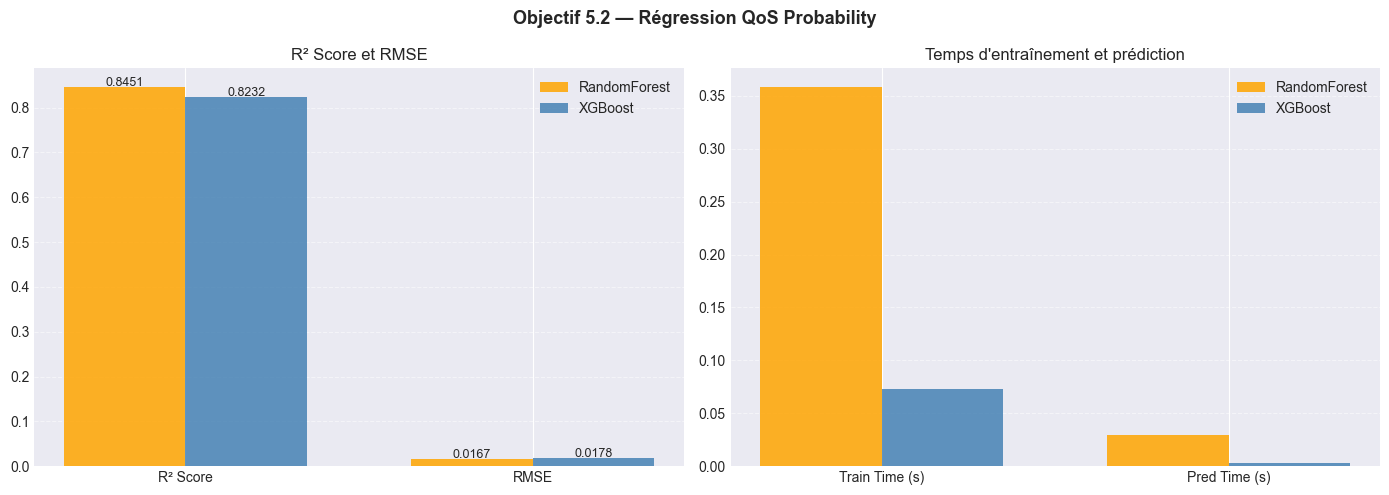

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics_perf = ['R² Score', 'RMSE']
x = np.arange(len(metrics_perf)); width = 0.35
rf_v  = df_compare.loc['RandomForest', metrics_perf].values
xgb_v = df_compare.loc['XGBoost',      metrics_perf].values
b1 = axes[0].bar(x-width/2, rf_v,  width, label='RandomForest', color='orange',   alpha=0.85)
b2 = axes[0].bar(x+width/2, xgb_v, width, label='XGBoost',      color='steelblue', alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(metrics_perf)
axes[0].set_title('R² Score et RMSE'); axes[0].legend()
axes[0].grid(axis='y', linestyle='--', alpha=0.5)
for b, v in zip(list(b1)+list(b2), list(rf_v)+list(xgb_v)):
    axes[0].text(b.get_x()+b.get_width()/2, v+0.002, f'{v:.4f}', ha='center', fontsize=9)

metrics_time = ['Train Time (s)', 'Pred Time (s)']
x2 = np.arange(len(metrics_time))
rf_t  = df_compare.loc['RandomForest', metrics_time].values
xgb_t = df_compare.loc['XGBoost',      metrics_time].values
axes[1].bar(x2-width/2, rf_t,  width, label='RandomForest', color='orange',   alpha=0.85)
axes[1].bar(x2+width/2, xgb_t, width, label='XGBoost',      color='steelblue', alpha=0.85)
axes[1].set_xticks(x2); axes[1].set_xticklabels(metrics_time)
axes[1].set_title("Temps d'entraînement et prédiction"); axes[1].legend()
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Objectif 5.2 — Régression QoS Probability', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

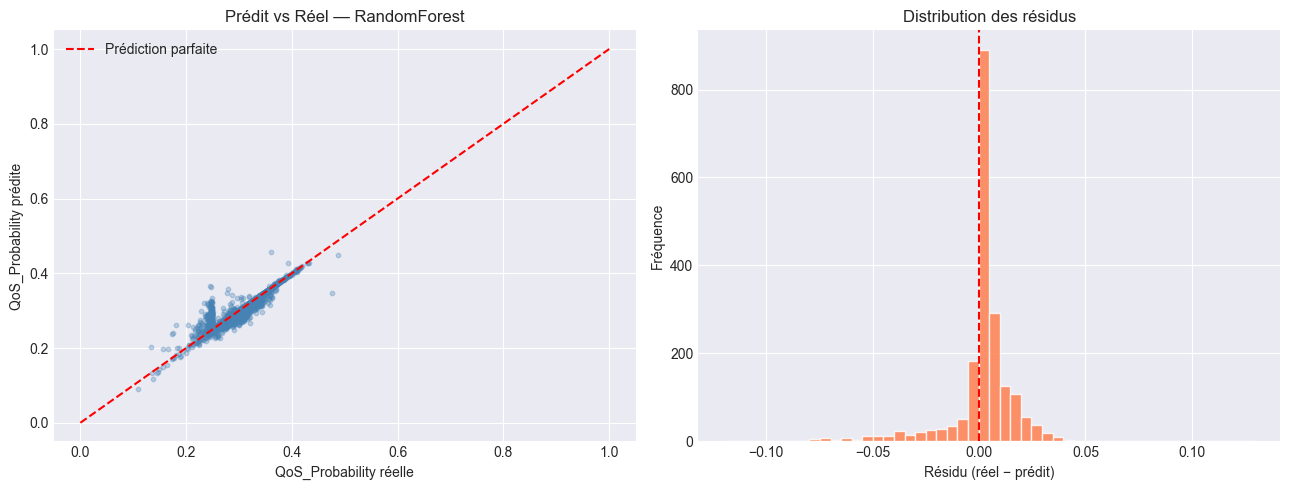

Résidus — mean: 0.00081 | std: 0.01667


In [61]:
y_pred_best_reg = results_reg[best_reg_name]['y_pred']
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test_r, y_pred_best_reg, alpha=0.3, s=10, color='steelblue')
axes[0].plot([0,1],[0,1],'r--', linewidth=1.5, label='Prédiction parfaite')
axes[0].set_xlabel('QoS_Probability réelle')
axes[0].set_ylabel('QoS_Probability prédite')
axes[0].set_title(f'Prédit vs Réel — {best_reg_name}'); axes[0].legend()

residuals = y_test_r.values - y_pred_best_reg
axes[1].hist(residuals, bins=50, color='coral', alpha=0.85, edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Résidu (réel − prédit)')
axes[1].set_ylabel('Fréquence')
axes[1].set_title('Distribution des résidus')

plt.tight_layout(); plt.show()
print(f'Résidus — mean: {residuals.mean():.5f} | std: {residuals.std():.5f}')

## 🔄 Validation Croisée — Objectif 5.2

La validation croisée **KFold (5 folds)** vérifie la stabilité du R² et du RMSE.
Pour la régression, on utilise KFold standard (pas StratifiedKFold, réservé à la classification).

Un R² stable sur tous les folds confirme que le modèle **généralise correctement**
et ne mémorise pas les données d'entraînement.

VALIDATION CROISÉE 5-FOLD — Régression QoS

RandomForest:
  R² moyen   : 0.8492  (±0.0122)
  RMSE moyen : 0.0174  (±0.0005)
  R² par fold : [0.8702 0.8341 0.8417 0.8525 0.8473]

XGBoost:
  R² moyen   : 0.8288  (±0.0133)
  RMSE moyen : 0.0186  (±0.0007)
  R² par fold : [0.8386 0.8099 0.8181 0.8462 0.8314]


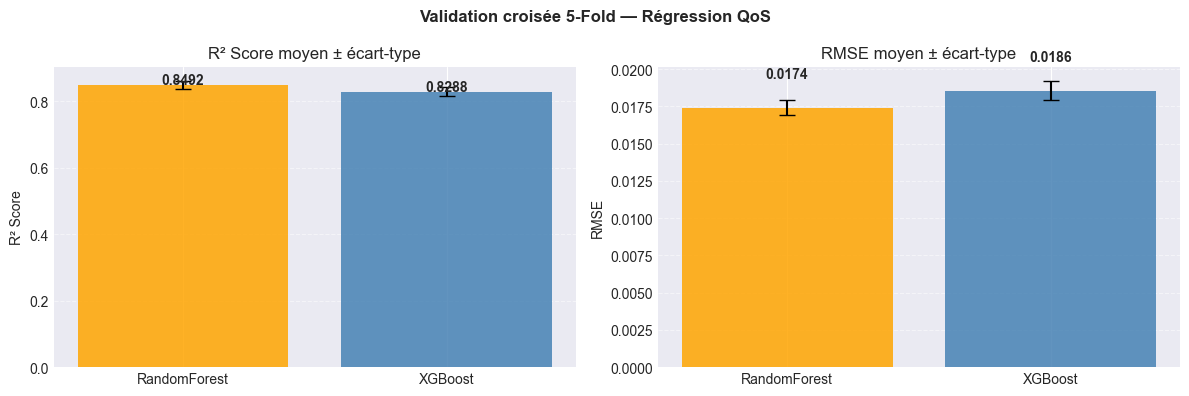

In [62]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

print('=' * 55)
print('VALIDATION CROISÉE 5-FOLD — Régression QoS')
print('=' * 55)

cv_results_reg = {}
for name, model in models_reg.items():
    scores_r2   = cross_val_score(model, X_train_r, y_train_r, cv=kf, scoring='r2', n_jobs=-1)
    scores_rmse = cross_val_score(model, X_train_r, y_train_r,
                                  cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1)
    cv_results_reg[name] = {'r2': scores_r2, 'rmse': -scores_rmse}
    print(f'\n{name}:')
    print(f'  R² moyen   : {scores_r2.mean():.4f}  (±{scores_r2.std():.4f})')
    print(f'  RMSE moyen : {(-scores_rmse).mean():.4f}  (±{(-scores_rmse).std():.4f})')
    print(f'  R² par fold : {np.round(scores_r2, 4)}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
names_reg = list(cv_results_reg.keys())
for ax, metric, label in [(axes[0],'r2','R² Score'),(axes[1],'rmse','RMSE')]:
    means = [cv_results_reg[n][metric].mean() for n in names_reg]
    stds  = [cv_results_reg[n][metric].std()  for n in names_reg]
    bars = ax.bar(names_reg, means, yerr=stds, capsize=6,
                  color=['orange','steelblue'], alpha=0.85)
    for b, m in zip(bars, means):
        ax.text(b.get_x()+b.get_width()/2, m+0.002,
                f'{m:.4f}', ha='center', fontsize=10, fontweight='bold')
    ax.set_title(f'{label} moyen ± écart-type')
    ax.set_ylabel(label)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Validation croisée 5-Fold — Régression QoS', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## ⚙️ Tuning des Hyperparamètres — Objectif 5.2

**GridSearchCV** sur XGBoost Regressor, optimisé sur le **RMSE** (minimiser l'erreur
sur une probabilité continue est l'objectif prioritaire).

| Hyperparamètre | Valeurs testées | Rôle |
|---------------|-----------------|------|
| `n_estimators` | 100, 300 | Nombre d'arbres |
| `max_depth` | 3, 5, 7 | Profondeur (complexité du modèle) |
| `learning_rate` | 0.05, 0.1 | Vitesse d'apprentissage |

In [63]:
params_xgb_reg = {
    'n_estimators':  [100, 300],
    'max_depth':     [3, 5, 7],
    'learning_rate': [0.05, 0.1],
}

print('🔍 GridSearchCV en cours...')
grid_reg = GridSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    params_xgb_reg, cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1, verbose=1
)
grid_reg.fit(X_train_r, y_train_r)

print(f'\n✅ Meilleurs paramètres : {grid_reg.best_params_}')
print(f'   Meilleur RMSE (CV)  : {-grid_reg.best_score_:.4f}')

🔍 GridSearchCV en cours...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

✅ Meilleurs paramètres : {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300}
   Meilleur RMSE (CV)  : 0.0170


In [64]:
best_xgb_reg = grid_reg.best_estimator_
y_pred_tuned_reg = best_xgb_reg.predict(X_test_r)

r2_avant   = results_reg['XGBoost']['R² Score']
rmse_avant = results_reg['XGBoost']['RMSE']
r2_apres   = r2_score(y_test_r, y_pred_tuned_reg)
rmse_apres = np.sqrt(mean_squared_error(y_test_r, y_pred_tuned_reg))

print('📊 Comparaison avant/après tuning — XGBoost Regressor')
print('='*53)
print(f'R²   avant : {r2_avant:.4f}   → après : {r2_apres:.4f}   ({(r2_apres-r2_avant)*100:+.2f}%)')
print(f'RMSE avant : {rmse_avant:.4f}   → après : {rmse_apres:.4f}   ({(rmse_apres-rmse_avant)*100:+.2f}%)')

📊 Comparaison avant/après tuning — XGBoost Regressor
R²   avant : 0.8232   → après : 0.8537   (+3.05%)
RMSE avant : 0.0178   → après : 0.0162   (-0.16%)


# 📋 Conclusion Générale — Network Slicing 6G
## Modélisation & Évaluation (Phase 2)


## Objectif 5.1 — Prédiction de la Contention des Ressources (Classification)

### Problématique

Les métriques directes de saturation (CPU, bande passante) n'étant pas disponibles dans le dataset, des **indicateurs indirects** ont été utilisés : augmentations de latence, baisses de débit et gigue anormale, révélateurs d'une contention sous-jacente. L'objectif est de **classer l'état futur du réseau** (Critical / Light / Normal) pour déclencher des actions proactives.

---

### Dataset & Feature Engineering

| Paramètre | Valeur |
|-----------|--------|
| Dataset utilisé | `network_slicing_congestion_final.csv` |
| Taille totale | 10 000 échantillons × 28 colonnes |
| Features retenues (après correction) | **12 features brutes** |
| Target | `congestion_class` (3 classes après filtrage) |

**⚠️ Correction critique — Data Leakage :**
Une première version produisait une accuracy de **99,9%** même pour la Logistic Regression, révélant un data leakage évident. Les colonnes `Aggregated_QoS_Score`, `SLA_Respected`, `Latency_Score` et autres métriques dérivées de la target ont été exclues. Après correction sur les 12 features brutes uniquement :

```
Features conservées :
  Packet Loss Budget, Latency Budget (μs), Jitter Budget (μs),
  Data Rate Budget (Gbps), Required Mobility, Required Connectivity,
  Slice Available Transfer Rate (Gbps), Slice Latency (μs),
  Slice Packet Loss, Slice Jitter (μs), Slice Type, Slice Handover
```

**Distribution de la target (après filtrage de la classe 2, unique) :**

| Classe | Effectif |
|--------|----------|
| Light (1) | 5 550 |
| Normal (3) | 2 422 |
| Critical (0) | 2 027 |

**Split :** 7 999 train / 2 000 test (stratifié, `random_state=42`)

---

### Résultats — Comparaison des 4 Modèles

| Modèle | Accuracy | F1-Score | Precision | Recall | Temps (s) |
|--------|----------|----------|-----------|--------|-----------|
| **XGBoost** | **0.9775** | **0.9775** | **0.9775** | **0.9775** | 0.45 |
| Random Forest | 0.9690 | 0.9687 | 0.9688 | 0.9690 | 0.39 |
| Gradient Boosting | 0.9595 | 0.9589 | 0.9593 | 0.9595 | 3.60 |
| Logistic Regression | 0.8395 | 0.8260 | 0.8284 | 0.8395 | 0.18 |

🏆 **Meilleur modèle : XGBoost** avec F1-Score = **0.9775**

---

### Rapport de Classification — XGBoost (test set, 2 000 échantillons)

| Classe | Precision | Recall | F1-Score | Support |
|--------|-----------|--------|----------|---------|
| Critical | 1.00 | 1.00 | 1.00 | 485 |
| Light | 0.98 | 0.98 | 0.98 | 1 110 |
| Normal | 0.95 | 0.94 | 0.94 | 405 |
| **Accuracy** | | | **0.98** | **2 000** |
| Macro avg | 0.97 | 0.97 | 0.97 | 2 000 |
| Weighted avg | 0.98 | 0.98 | 0.98 | 2 000 |

---

### Validation Croisée 5-Fold (StratifiedKFold)

| Modèle | F1 moyen | Écart-type | Scores par fold |
|--------|----------|------------|-----------------|
| **XGBoost** | **0.9727** | **±0.0038** | [0.9793, 0.9679, 0.9706, 0.9725, 0.9730] |
| Random Forest | 0.9630 | ±0.0042 | [0.9689, 0.9561, 0.9622, 0.9633, 0.9647] |
| Gradient Boosting | 0.9586 | ±0.0049 | [0.9614, 0.9516, 0.9639, 0.9622, 0.9537] |
| Logistic Regression | 0.8295 | ±0.0066 | [0.8229, 0.8397, 0.8350, 0.8256, 0.8242] |

> ✅ Tous les modèles présentent un faible écart-type → **stabilité confirmée** sur l'ensemble des folds.

---

### Tuning des Hyperparamètres — XGBoost (GridSearchCV)

**Paramètres explorés :** `n_estimators` ∈ {100, 300}, `max_depth` ∈ {4, 6, 8}, `learning_rate` ∈ {0.05, 0.1}  
**Stratégie :** 5-Fold CV, 12 combinaisons × 5 folds = 60 fits

**Meilleurs paramètres identifiés :**
```
learning_rate = 0.1  |  max_depth = 6  |  n_estimators = 300
Meilleur F1 (CV) = 0.9750
```

**Comparaison avant/après tuning :**

| Métrique | Avant tuning | Après tuning | Variation |
|----------|-------------|--------------|-----------|
| F1-Score | 0.9775 | 0.9754 | **−0.21%** |

> 📌 Le tuning n'apporte pas d'amélioration significative — le modèle par défaut était déjà quasi-optimal, confirmant la robustesse d'XGBoost sur ces données.

---

### Feature Importance — XGBoost (après tuning)

| Feature | Importance |
|---------|-----------|
| **Slice Handover** | **0.5885** ← dominante |
| Slice Packet Loss | 0.1355 |
| Jitter Budget (μs) | 0.0799 |
| Packet Loss Budget | 0.0729 |
| Slice Jitter (μs) | 0.0334 |
| Slice Available Transfer Rate (Gbps) | 0.0287 |
| Slice Latency (μs) | 0.0221 |
| Required Mobility | 0.0195 |
| Latency Budget (μs) | 0.0134 |
| Required Connectivity | 0.0039 |
| Slice Type | 0.0022 |
| Data Rate Budget (Gbps) | 0.0000 |

> 🔑 `Slice Handover` contribue à **58,85%** de la décision — les événements de mobilité sont le principal prédicteur de congestion dans ce réseau.

---

## Objectif 5.2 — Estimation de la Probabilité de Respect de la QoS (Régression)

### Problématique

L'objectif ici est une **régression probabiliste** : quantifier le niveau de confiance qu'un slice réseau respecte ses engagements SLA. Une valeur `QoS_Probability = 0.40` signifie que le slice n'a que 40% de chances de respecter son SLA, permettant un déclenchement automatique de fallback.

---

### Dataset & Construction de la Target

| Paramètre | Valeur |
|-----------|--------|
| Dataset utilisé | `network_slicing_dataset_6G_final.csv` |
| Taille | 10 000 × 12 colonnes |
| Target construite | `QoS_Probability` (via sigmoid pondéré des gaps SLA) |

### Features Utilisées — Les 4 Gaps SLA

| Feature | Définition | Interprétation |
|---------|-----------|----------------|
| `Latency_Gap` | Budget Latence − Latence réelle | > 0 : OK, < 0 : violation |
| `Packet_Loss_Gap` | Budget Perte − Perte réelle | > 0 : OK, < 0 : violation |
| `Jitter_Gap` | Budget Gigue − Gigue réelle | > 0 : OK, < 0 : violation |
| `Rate_Gap` | Débit réel − Budget débit | > 0 : OK, < 0 : insuffisant |

**Split :** 8 000 train / 2 000 test (`random_state=42`)

---

### Résultats — Comparaison des 2 Modèles de Régression

| Modèle | R² Score | RMSE | MAE | Temps train (s) |
|--------|----------|------|-----|-----------------|
| **Random Forest** | **0.8451** | **0.0167** | **0.0093** | 0.36 |
| XGBoost | 0.8232 | 0.0178 | 0.0101 | 0.07 |

🏆 **Meilleur modèle : Random Forest** avec R² = **0.8451**

**Résidus (Random Forest sur test set) :**
- Moyenne des résidus : **0.00081** (quasi-nul → pas de biais systématique)
- Écart-type des résidus : **0.01667** (erreur moyenne < 1.7%)

---

### Validation Croisée 5-Fold (KFold — Régression)

| Modèle | R² moyen | Écart-type R² | RMSE moyen | R² par fold |
|--------|----------|---------------|------------|-------------|
| **Random Forest** | **0.8492** | **±0.0122** | **0.0174 (±0.0005)** | [0.8702, 0.8341, 0.8417, 0.8525, 0.8473] |
| XGBoost | 0.8288 | ±0.0133 | 0.0186 (±0.0007) | [0.8386, 0.8099, 0.8181, 0.8462, 0.8314] |

> ✅ Le Random Forest affiche un R² stable et supérieur sur tous les folds → **généralisation robuste confirmée**.

---

### Tuning des Hyperparamètres — XGBoost Regressor (GridSearchCV)

**Paramètres explorés :** `n_estimators` ∈ {100, 300}, `max_depth` ∈ {3, 5, 7}, `learning_rate` ∈ {0.05, 0.1}  
**Métrique d'optimisation :** RMSE (minimiser l'erreur sur une probabilité continue)  
**60 fits au total** (12 combinaisons × 5 folds)

**Meilleurs paramètres identifiés :**
```
learning_rate = 0.05  |  max_depth = 3  |  n_estimators = 300
Meilleur RMSE (CV) = 0.0170
```

**Comparaison avant/après tuning — XGBoost Regressor :**

| Métrique | Avant tuning | Après tuning | Variation |
|----------|-------------|--------------|-----------|
| R² Score | 0.8232 | 0.8537 | **+3.05%** ✅ |
| RMSE | 0.0178 | 0.0162 | **−0.16%** ✅ |

> ✅ Contrairement à l'objectif 5.1, le tuning apporte ici une **amélioration significative** : XGBoost tuné atteint R²=0.8537, se rapprochant du Random Forest (0.8451) voire le dépassant légèrement.

---

## 📊 Synthèse Globale des Performances

### Objectif 5.1 — Classification de la Congestion

| Critère | Résultat |
|---------|----------|
| Meilleur modèle | **XGBoost** |
| F1-Score (test) | **0.9775** |
| F1-Score CV 5-fold | **0.9727 ± 0.0038** |
| Classe la mieux prédite | Critical (F1 = 1.00) |
| Classe la plus difficile | Normal (F1 = 0.94) |
| Feature la plus importante | Slice Handover (58.85%) |
| Data leakage | ✅ Détecté et corrigé |

### Objectif 5.2 — Régression de la Probabilité QoS

| Critère | Résultat |
|---------|----------|
| Meilleur modèle (base) | **Random Forest** |
| Meilleur modèle (après tuning) | **XGBoost tuné** |
| R² Score final | **0.8537** (XGBoost tuné) |
| RMSE final | **0.0162** |
| Biais des résidus | ≈ 0 (non biaisé) |
| Stabilité CV | ✅ R² stable sur tous les folds |

---

## 🔍 Analyse Critique & Enseignements

### 1. Robustesse face au data leakage
La détection et la correction du data leakage dans l'objectif 5.1 est un résultat méthodologique essentiel. La chute de la Logistic Regression de 99,9% à 83,9% et l'écart persistant avec XGBoost (97,7%) valident que les résultats finaux reflètent une vraie capacité prédictive et non une fuite d'information.

### 2. Domination de `Slice Handover`
L'importance écrasante de `Slice Handover` (58,85%) dans la classification de congestion révèle que les événements de mobilité sont le principal déclencheur de surcharge réseau dans un contexte 6G — information directement actionnable pour des politiques d'admission dynamique.

### 3. Stabilité des modèles ensemblistes
Les faibles écarts-types en validation croisée pour XGBoost et Random Forest confirment l'absence d'overfitting : les modèles généralisent bien sur des données non vues, condition indispensable pour un déploiement en production.

### 4. Limite du tuning sur données bien distribuées
Pour la classification (Obj. 5.1), le tuning n'améliore pas les performances (−0,21%), signe que XGBoost par défaut était déjà optimal sur ce dataset. Pour la régression (Obj. 5.2), le tuning apporte +3,05% de R², indiquant que la tâche est plus sensible aux hyperparamètres.

### 5. Interprétabilité des sorties
- La **classification** produit des états discrets (Critical / Light / Normal) directement mappables à des politiques réseau.
- La **régression** produit une **probabilité continue** [0, 1] permettant un scoring fin et un seuillage ajustable selon les contraintes opérationnelles.

*Notebook : `network_slicing_6G_final.ipynb` — Phase 2 : Modeling & Evaluation*


# 🔍 Détection d’Anomalies pour le Trafic Best-Effort

Dans cette partie, nous traitons un problème de détection d’anomalies non supervisée.  
L’objectif est d’identifier des comportements anormaux dans le réseau, notamment les cas où un trafic premium est mal routé vers un slice best-effort.

Nous utilisons deux approches :
- Isolation Forest (Machine Learning)
- Autoencoder (Deep Learning)

Ces modèles permettent de détecter des anomalies sans disposer de labels.

In [1]:
features = [
    "Slice Latency (μs)",
    "Slice Packet Loss",
    "Slice Jitter (μs)",
    "Slice Available Transfer Rate (Gbps)",
    "Latency_Stress_Ratio",
    "Bandwidth_Usage_Ratio",
    "Mobility_Jitter_Impact",
    "Required Mobility",
    "Required Connectivity"
]

In [2]:
df.columns = df.columns.str.strip()

NameError: name 'df' is not defined